In [1]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [8]:
import sys
sys.path.append("../../")

In [ ]:
from graphnet_LPDM_emulator.model.data.load_data import LoadSquareSatelliteData
from graphnet_LPDM_emulator.model.data.datasets import get_square_satellite_inputs

In [ ]:
import xarray as xr
import numpy as np

import matplotlib.pyplot as plt
import datetime
import pandas as pd


In [5]:
import joblib
from pathlib import Path

## testing the whole pipeline

In [32]:
# load data and some test data
data = LoadSquareSatelliteData(201604, freq=3, size=50, region="SAHARA", verbose=True, fill_outofdomain_with="nans")

data_test = LoadSquareSatelliteData(201609, freq=3, size=50, region="SAHARA", verbose=True, fill_outofdomain_with="nans")

---- LOADING FOOTPRINTS
Loading footprint data from /group/chem/acrg/LPDM/fp_NAME_pre20210701/NORTHAFRICA/*SAHARA*NORTHAFRICA_201604*.nc
reduced the number of datapoints by frequency 3
Loading 297 footprints
----- Cutting footprints to square of size 50
using new cut satellite data!!!
Padding lat by (0, 12) cells (S, N) with mode='nans'

 ---- LOADING MET
Loading meteorology from /group/chem/acrg/met_archive/UM/NORTHAFRICA/NORTHAFRICA_Met_201604*.nc
----- Cutting met
calculated wind_angle and wind_speed from x_wind and y_wind

---- LOADING TOPOG
trying to load topography from /group/chem/acrg/LPDM/topog_NAME/TopogUMG_Mk8_global.nc
----- Cutting topog
---- All done!
---- LOADING FOOTPRINTS
Loading footprint data from /group/chem/acrg/LPDM/fp_NAME_pre20210701/NORTHAFRICA/*SAHARA*NORTHAFRICA_201609*.nc
reduced the number of datapoints by frequency 3
Loading 407 footprints
----- Cutting footprints to square of size 50
using new cut satellite data!!!
Padding lat by (0, 12) cells (S, N) with

In [8]:
# the footprints are stored in data.fp_xr
data.fp_xr

<xarray.Dataset> Size: 3MB
Dimensions:      (time: 297, lat: 50, lon: 50)
Coordinates:
  * time         (time) datetime64[ns] 2kB 2016-04-01T12:02:40 ... 2016-04-30...
  * lon          (lon) int64 400B 0 1 2 3 4 5 6 7 8 ... 42 43 44 45 46 47 48 49
  * lat          (lat) int64 400B 0 1 2 3 4 5 6 7 8 ... 42 43 44 45 46 47 48 49
Data variables:
    fp           (time, lat, lon) float32 3MB dask.array<chunksize=(100, 50, 50), meta=np.ndarray>
    lat_coords   (time, lat) float64 119kB dask.array<chunksize=(100, 50), meta=np.ndarray>
    lon_coords   (time, lon) float32 59kB dask.array<chunksize=(100, 50), meta=np.ndarray>
    release_lat  (time) float32 1kB dask.array<chunksize=(100,), meta=np.ndarray>
    release_lon  (time) float32 1kB dask.array<chunksize=(100,), meta=np.ndarray>
Attributes:
    max_level:  17
    author:     lw13938
    created:    2020-01-22 17:05:32.659151

In [33]:
met_params =  {
        "met_variables":{"x_wind":[3,9,15], "y_wind":[3,9,15], "atmosphere_boundary_layer_thickness":[], "surface_air_pressure":[], "wind_speed":[3,9,15], "wind_angle":[3,9,15]},
        "static_variables":["lat_coords", "lon_coords", "distance_centre", "x_coords", "y_coords", "topog"],
        "time_deltas":[6]
    }

In [34]:
# load the inputs
inputs = get_square_satellite_inputs(data, **met_params)

------------------------
---EXTRACTING MET DATA---
extracting met at t-H for H in: [0, 6]
calculated wind_angle and wind_speed from x_wind and y_wind
Setting up variables with levels: ['x_wind', 'y_wind', 'wind_speed', 'wind_angle']
Setting up surface variables: ['atmosphere_boundary_layer_thickness', 'surface_air_pressure']
Setting up static variables: ['lat_coords', 'lon_coords', 'distance_centre', 'x_coords', 'y_coords', 'topog']
variable distance_centre was not found in the list of known functions!


In [35]:
#and the same for the test data
test_inputs = get_square_satellite_inputs(data_test, **met_params)

------------------------
---EXTRACTING MET DATA---
extracting met at t-H for H in: [0, 6]
calculated wind_angle and wind_speed from x_wind and y_wind
Setting up variables with levels: ['x_wind', 'y_wind', 'wind_speed', 'wind_angle']
Setting up surface variables: ['atmosphere_boundary_layer_thickness', 'surface_air_pressure']
Setting up static variables: ['lat_coords', 'lon_coords', 'distance_centre', 'x_coords', 'y_coords', 'topog']
variable distance_centre was not found in the list of known functions!


In [ ]:
from graphnet_LPDM_emulator.model.data.datasets import InputsDataset, DefaultInputsScaler, FootprintDataset, LogAndShiftMeanFpScaler, LogAndShiftFpScaler

In [42]:
# first normalize the inputs 
# we fit the scaler on a subsample of the data to speed up the process
inputs_dataset = InputsDataset(inputs, scaler=DefaultInputsScaler, scaler_params={"fit_on_subsample": 0.5, "verbose": True}, verbose=True )
inputs_dataset.fit()
# then apply transform to the test set
inputs_scaled = inputs_dataset.transform(inputs)
test_inputs_scaled = inputs_dataset.transform(test_inputs)

fit_on_subsample is 0.5, so only using 148 samples to fit the scaler
fitting standardise scaler for var atmosphere_boundary_layer_thickness
fitting minmax scaler for var lat_coords
fitting minmax scaler for var lon_coords
fitting standardise scaler for var surface_air_pressure
fitting minmax scaler for var topog
fitting standardise scaler for var wind_angle
fitting standardise scaler for var wind_speed
fitting minmax scaler for var x_coords
fitting standardise scaler for var x_wind
fitting minmax scaler for var y_coords
fitting standardise scaler for var y_wind


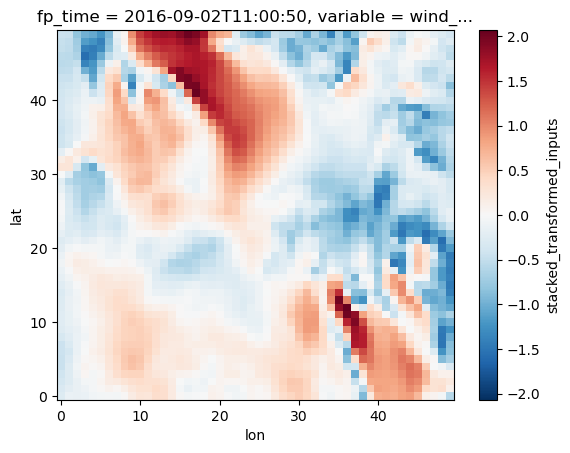

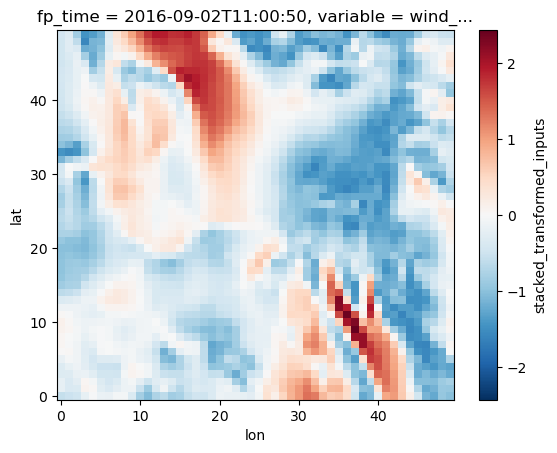

In [14]:
# the inputs, and the scaled inputs, store the data as a stacked array, 
# stacked along the variable_name dimension with shape (variable_name, levels, delta_time)
# e.g. we can plot the x_wind at level 3 for a particular timepoint, at delta_time = 0 and at delta_time = 6 (below)
# it will take a bit to load, it's doing the calculation on the fly
# the same data could be selected with test_inputs_scaled.sel(variable="wind_speed", level=3, delta_time=0) or test_inputs_scaled.sel(variable="wind_speed", level=3, delta_time=6)
test_inputs_scaled.sel(variable_name= ('wind_speed', 3, 0)).isel(fp_time=0).plot()
plt.show()
test_inputs_scaled.sel(variable_name= ('wind_speed', 3, 6)).isel(fp_time=0).plot()

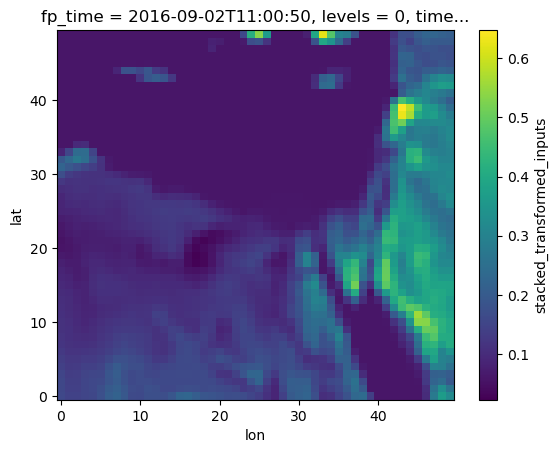

In [15]:
test_inputs_scaled.sel(variable = 'topog').isel(fp_time=0).plot()

In [38]:
# we can also transform the footprints
# for example, apply a log and shift scaler, which is common for footprint data, to make the distribution more normal and easier to learn from
fpds = FootprintDataset(data.fp_xr, scaler=LogAndShiftMeanFpScaler, scaler_params={"minimum_oom": 6})
transformed_fps = fpds.fit_transform()

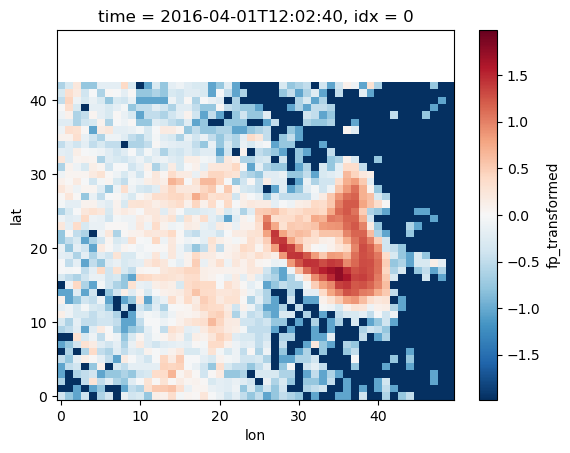

In [39]:
t = transformed_fps.fp_transformed.isel(time=0)
t.plot()

In [18]:
transformed_fps_test = fpds.transform(data_test.fp_xr)
# we can also inverse transform the footprints back to the original space if needed, e.g. for plotting or evaluation
inverse_transformed_fp = fpds.inverse_transform(transformed_fps_test.fp_transformed)

In [19]:
# OR apply a log and shift scaler that doesn't use the mean and can be strictly non-negative
fpds = FootprintDataset(data.fp_xr, scaler=LogAndShiftFpScaler, scaler_params={"minimum_oom": 6})
transformed_fps = fpds.fit_transform()

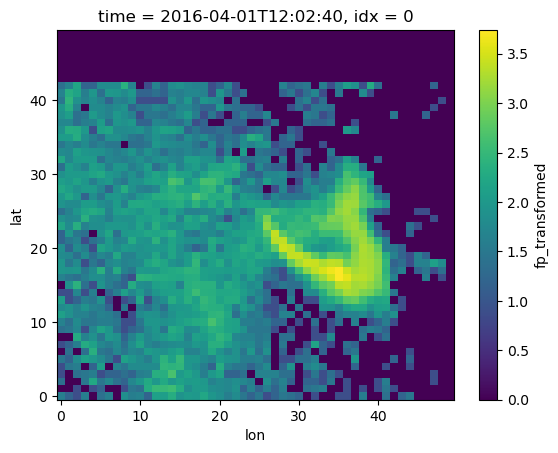

In [20]:
t = transformed_fps.fp_transformed.isel(time=0)
t.plot()

### setting up an xbatcher

In [ ]:
import torch
import xbatcher as xb
import xbatcher.loaders.torch

In [43]:
inputs_scaled

<xarray.DataArray 'stacked_transformed_inputs' (variable_name: 33,
                                                fp_time: 297, lat: 50, lon: 50)> Size: 98MB
dask.array<concatenate, shape=(33, 297, 50, 50), dtype=float32, chunksize=(1, 297, 50, 50), chunktype=numpy.ndarray>
Coordinates:
  * lat            (lat) int64 400B 0 1 2 3 4 5 6 7 ... 42 43 44 45 46 47 48 49
  * lon            (lon) int64 400B 0 1 2 3 4 5 6 7 ... 42 43 44 45 46 47 48 49
  * fp_time        (fp_time) datetime64[ns] 2kB 2016-04-01T12:02:40 ... 2016-...
  * variable       (variable_name) object 264B 'atmosphere_boundary_layer_thi...
  * levels         (variable_name) int64 264B 0 0 0 0 0 0 0 ... 0 3 3 9 9 15 15
  * time_delta     (variable_name) int64 264B 0 6 0 0 0 6 0 0 ... 0 0 6 0 6 0 6
  * variable_name  (variable_name) object 264B MultiIndex
Attributes:
    transformer:       DefaultInputsScaler
    minmax_variables:  ['land_cover', 'topog', 'x_coords', 'y_coords', 'lat_c...
    generated_on:      2026-03-31 20:32:46.929446

In [61]:
from graphnet_LPDM_emulator.model.data.datasets import make_dataloader

In [58]:
dataloader = make_dataloader(inputs_scaled, transformed_fps.fp_transformed, batch_size=10, randomize=False)

In [59]:
train_features, train_labels = next(iter(dataloader))

In [60]:
train_features.shape, train_labels.shape

(torch.Size([10, 50, 50, 33]), torch.Size([10, 50, 50]))